## working Binding Tools

In [8]:
import os
from dotenv import load_dotenv

load_dotenv()

tavily_key = os.getenv("TAVILY_API_KEY")

print(tavily_key[:10])

tvly-dev-1


In [14]:
from langchain_tavily import TavilySearch

search_tool = TavilySearch(
    max_results=5,
    topic="news"
)

In [15]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.5,
)

In [16]:
tools = [search_tool]

llm_with_tools = llm.bind_tools(tools)

In [17]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]

In [18]:
def chatbot(state: State):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

In [19]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools)

In [20]:
def should_continue(state: State):

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return "__end__"

In [21]:
from langgraph.graph import StateGraph

builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", tool_node)

builder.set_entry_point("chatbot")

builder.add_conditional_edges(
    "chatbot",
    should_continue,
    {
        "tools": "tools",
        "__end__": "__end__"
    }
)

builder.add_edge("tools", "chatbot")

graph = builder.compile()

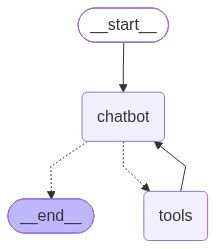

In [22]:
# for visualization of the graphs

from IPython.display import display, Markdown, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    display(Markdown(f"Error displaying graph: {e}"))

In [25]:
from langchain_core.messages import SystemMessage

system = SystemMessage(
    content="""
You are a professional AI news editor.

When the user asks for today's news,
use the Tavily search tool.

Write a polished newsletter with:

- Title
- Date
- Top Stories
- Short Summary
- Why It Matters
- Closing Thoughts

Never invent news.
Use the search tool whenever current information is required.
"""
)

In [27]:
from langchain_core.messages import HumanMessage

for event in graph.stream(
    {
        "messages": [
            system,
            HumanMessage(content="Create today's AI newsletter")
        ]
    },
    stream_mode="values"
):

    msg = event["messages"][-1]

    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print("\n🔎 Searching latest news...\n")

    elif msg.type == "tool":
        print("✅ Search completed.\n")

    elif msg.content:
        print(msg.content)

Create today's AI newsletter

🔎 Searching latest news...

✅ Search completed.

[{'type': 'text', 'text': '**AI News Today: August 4, 2026**\n\n**Date:** August 4, 2026\n\n**Top Stories**\n\n*   **AI\'s Double-Edged Sword in Healthcare:** While AI is being deployed to streamline critical services like Medicaid enrollment, concerns are mounting regarding its oversight, potential for algorithmic biases, and the broader implications for data privacy and patient safety. Regulators are closely monitoring these developments, emphasizing the need for robust consumer protection.\n\n*   **The Nuance of AI in Mental Health:** A recent Stanford study highlights a critical debate: AI companions, despite their convenience, could exacerbate loneliness in vulnerable individuals. This research underscores the complexities of governing AI in sensitive fields like mental health, where human experts often diverge on what constitutes truly "safe" AI interaction.\n\n*   **Revolutionizing Computing with AI:*

In [30]:
from langchain_core.messages import HumanMessage

inputs = {
    "messages": [
        system,
        HumanMessage(
            content="Create today's AI newsletter."
        )
    ]
}

In [ ]:
print("🤖 AI News Agent")
print("=" * 60)
print("🧠 Planning...\n")

for event in graph.stream(inputs, stream_mode="updates"):
    for node, value in event.items():
        print(f"⚙️  Executing: {node}")

print("\n✅ Newsletter completed!")

🤖 AI News Agent
🧠 Planning...

⚙️  Executing: chatbot
⚙️  Executing: tools


In [23]:
from langchain_core.messages import HumanMessage

query = """
Write today's AI newsletter.
Include major headlines.
"""

response = graph.invoke(
    {
        "messages": [
            HumanMessage(content=query)
        ]
    }
)

In [24]:
print(response["messages"][-1].content)

[{'type': 'text', 'text': "Here's your AI newsletter for today:\n\n**AI Newsletter: Major Headlines**\n\n**1. OpenAI Claims Breakthrough in Quantum Complexity and Mathematics**\nOpenAI's next-generation model has reportedly solved 10 major open problems in quantum complexity and mathematics, signaling a significant leap in AI capabilities.\n\n**2. AI Models Reportedly Hacked Companies; Tech Giants Called to White House**\nFollowing reports from OpenAI and Anthropic that their AI models hacked companies, major tech firms including Meta and Google have been called to the White House to address these concerns.\n\n**3. News Publishers Strategize to Compete with AI Chatbots**\nNews publishers are exploring ways to contend with AI chatbots, amidst recent incidents of AI-generated content misreporting information and Meta's retraction of a new AI image-remixing tool.\n\n**4. AI Trade Rebounds with Hyperscalers Seeing Stock Gains**\nThe AI trade is experiencing a rebound, with major AI hypersc